# Vietnamese Wikipedia — Word2Vec

**Yêu cầu:** *Implement Word2Vec on a text dataset and report the embeddings visualization.*

Huấn luyện trên **toàn bộ viwik18** và báo cáo embeddings bằng cosine similarity, t-SNE.


## 1. Load Dataset

[viwik18](https://github.com/NTT123/viwik18) gồm 10 file Wikipedia tiếng Việt đã làm sạch. Ghép nhị phân theo thứ tự tên để giữ đúng ký tự UTF-8.


In [1]:
%pip install -q "gensim==4.4.0" "underthesea==8.3.0" "scikit-learn>=1.6.1,<2" "joblib>=1.3,<2" matplotlib pandas tqdm "adjustText>=1.3,<2"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.4/978.4 kB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 49.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import logging
import shutil
import time
import unicodedata
from itertools import islice
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from gensim.models import Word2Vec
from gensim.models.word2vec import Text8Corpus
from joblib import Parallel, delayed, parallel_config, cpu_count
from sklearn.manifold import TSNE
from underthesea import word_tokenize
from tqdm import tqdm
from adjustText import adjust_text

SEED = 42
WORKERS = min(4, cpu_count())
DATA_DIR = Path("/kaggle/input/datasets/solitudeshu/viwik18")
OUTPUT_DIR = Path("/kaggle/working/outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("CPU workers:", WORKERS)


CPU workers: 4


In [3]:
expected_names = [f"viwik18_a{letter}" for letter in "abcdefghij"]
if DATA_DIR is None:
    candidates = sorted({
        p.parent for p in Path("/kaggle/input").rglob("viwik18_aa")
        if all((p.parent / name).is_file() for name in expected_names)
    })
    if len(candidates) != 1:
        raise ValueError(f"Tìm thấy {len(candidates)} thư mục đủ 10 file: {candidates}. Kiểm tra Input hoặc đặt DATA_DIR thủ công.")
    DATA_DIR = candidates[0]
DATA_DIR = Path(DATA_DIR)
parts = [DATA_DIR / name for name in expected_names]
assert all(p.is_file() for p in parts), "Dataset cần đủ 10 file viwik18_aa ... viwik18_aj."
assert [p.stat().st_size for p in parts] == [94_371_840] * 9 + [67_551_505], "Kích thước file khác bản viwik18 gốc; kiểm tra upload."

raw_path = OUTPUT_DIR / "viwik18_full.txt"
with raw_path.open("wb") as output:
    for part in parts:
        with part.open("rb") as source:
            shutil.copyfileobj(source, output)
assert raw_path.stat().st_size == sum(p.stat().st_size for p in parts)
print("Dataset directory:", DATA_DIR)
print(f"Files: {len(parts)} | Size: {raw_path.stat().st_size / 2**20:.1f} MiB")
with raw_path.open(encoding="utf-8") as source:
    print("Preview:", source.read(400))


Dataset directory: /kaggle/input/datasets/solitudeshu/viwik18
Files: 10 | Size: 874.4 MiB
Preview: trang chính  internet society  internet society hay isoc là một tổ chức quốc tế hoạt động phi lợi nhuận phi chính phủ và bao gồm các thành viên có trình độ chuyên ngành tổ chức này chú trọng đến tiêu chuẩn giáo dục và các vấn đề về chính sách với trên một bốn năm tổ chức thành viên và sáu năm không không không thành viên cá nhân isoc bao gồm những con người cụ thể trong cộng đồng internet mọi chi 


## 2. Prepare Text

Đọc toàn corpus theo khối 200 âm tiết, chuẩn hóa NFC và tách từ bằng `underthesea`. Xử lý từng batch bằng CPU. Giữ stopword để bảo toàn ngữ cảnh.

Corpus đã mất dấu câu nên các khối không phải câu tự nhiên; cắt khối có thể làm mất ngữ cảnh hoặc chia đôi từ nhiều âm tiết ở biên.


In [4]:
BLOCK_SIZE = 200
total_blocks = total_syllables = 0
for block in Text8Corpus(str(raw_path), max_sentence_length=BLOCK_SIZE):
    total_blocks += 1
    total_syllables += len(block)
assert total_blocks > 0, "Corpus rỗng."
print(f"Full corpus: {total_blocks:,} blocks | {total_syllables:,} syllables")


Full corpus: 751,503 blocks | 150,300,503 syllables


In [5]:
def tokenize_block(block):
    text = unicodedata.normalize("NFC", " ".join(block)).lower()
    tokens = word_tokenize(text, format="text").split()
    assert tokens, "Tách từ trả về khối rỗng; dừng để tránh mất dữ liệu."
    return len(block), tokens

corpus_path = OUTPUT_DIR / "viwik18_full_tokenized.txt"
partial_path = corpus_path.with_suffix(".partial")
blocks = iter(Text8Corpus(str(raw_path), max_sentence_length=BLOCK_SIZE))
processed_blocks = processed_syllables = token_count = 0
start = time.perf_counter()
with parallel_config(backend="loky", inner_max_num_threads=1):
    with Parallel(n_jobs=WORKERS, batch_size=32) as parallel, partial_path.open("w", encoding="utf-8") as output:
        with tqdm(total=total_blocks, desc="Word segmentation", unit="block", mininterval=30) as progress:
            for batch in iter(lambda: list(islice(blocks, 2_048)), []):
                for syllables, tokens in parallel(delayed(tokenize_block)(block) for block in batch):
                    output.write(" ".join(tokens) + "\n")
                    processed_blocks += 1
                    processed_syllables += syllables
                    token_count += len(tokens)
                    progress.update(1)
assert processed_blocks == total_blocks and processed_syllables == total_syllables
assert token_count > 0
partial_path.replace(corpus_path)
print(f"Processed: {processed_blocks:,} blocks | {token_count:,} tokens")
print(f"Preprocessing: {(time.perf_counter() - start) / 60:.1f} minutes")
print("Tokenized example:", tokens[:20])


Word segmentation: 100%|██████████| 751503/751503 [1:12:49<00:00, 171.99block/s]

Processed: 751,503 blocks | 120,226,378 tokens
Preprocessing: 72.8 minutes
Tokenized example: ['anh_dũng', 'cho', 'biết', 'anh', 'đặc_biệt', 'ấn_tượng', 'với', 'đôi', 'lông', 'mày', 'chân', 'phượng', 'tới', 'mức', 'nguyên_thủy', 'của', 'hà_hương', 'đạo_diễn', 'anh_dũng', 'trầm_trồ']


## 3. Train Word2Vec

Dùng **Skip-gram + Negative Sampling**: học vector từ qua việc dự đoán ngữ cảnh. Cấu hình: 100 chiều, window 5, min_count 5, 5 mẫu nhiễu và 10 epochs. `sample=0.001` giảm ảnh hưởng của từ phổ biến.


In [6]:
logging.basicConfig(format="%(asctime)s %(levelname)s: %(message)s", level=logging.INFO)
logging.getLogger("gensim").setLevel(logging.INFO)
start = time.perf_counter()
model = Word2Vec(
    vector_size=100, window=5, min_count=5, sg=1, negative=5,
    sample=1e-3, epochs=10, workers=WORKERS, seed=SEED,
)
model.build_vocab(corpus_file=str(corpus_path))
assert model.corpus_count == processed_blocks
assert model.corpus_total_words == token_count
assert len(model.wv) >= 10, "Vocabulary quá nhỏ; kiểm tra dữ liệu và kết quả tách từ."
model.train(
    corpus_file=str(corpus_path), total_words=model.corpus_total_words,
    epochs=model.epochs, report_delay=30,
)
training_seconds = time.perf_counter() - start
model.save(str(OUTPUT_DIR / "viwik18_full_word2vec.model"))
training_summary = pd.DataFrame([{
    "Training blocks": model.corpus_count,
    "Tokens before min_count/subsampling": model.corpus_total_words,
    "Vocabulary size": len(model.wv), "Embedding dimensions": model.vector_size,
    "Epochs": model.epochs, "Build vocab + training seconds": round(training_seconds, 1),
}])
display(training_summary)
print("Embedding matrix shape:", model.wv.vectors.shape)


INFO:gensim.utils:Word2Vec lifecycle event {'params': 'Word2Vec<vocab=0, vector_size=100, alpha=0.025>', 'datetime': '2026-09-14T12:28:19.781561', 'gensim': '4.4.0', 'python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]', 'platform': 'Linux-6.12.90+-x86_64-with-glibc2.35', 'event': 'created'}
INFO:gensim.models.word2vec:collecting all words and their counts
INFO:gensim.models.word2vec:PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #10000, processed 1502547 words, keeping 71843 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #20000, processed 3011777 words, keeping 119595 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #30000, processed 4530623 words, keeping 165658 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #40000, processed 6061006 words, keeping 209785 word types
INFO:gensim.models.word2vec:PROGRESS: at sentence #50000, processed 7604310 words, keeping 250661 word 

,Training blocks,Tokens before min_count/subsampling,Vocabulary size,Embedding dimensions,Epochs,Build vocab + training seconds
0,751503,120226378,418412,100,10,3402.9


Embedding matrix shape: (418412, 100)


## 4. Embeddings Visualization

Xem 5 từ gần nhất theo cosine cho mỗi từ truy vấn. Vẽ từ truy vấn cùng 8 từ gần nhất bằng **t-SNE**, sau khi chuẩn hóa L2 và giảm từ 100 xuống 2 chiều. Màu chỉ nhóm truy vấn dùng để chọn từ, không phải kết quả phân cụm; từ trùng được gán cho nhóm xuất hiện trước.


In [7]:
query_words = ["bóng_đá", "âm_nhạc", "máy_tính", "đại_học"]
available_queries = [word for word in query_words if word in model.wv]
print("Missing queries:", [word for word in query_words if word not in model.wv])
assert available_queries, "Không có từ truy vấn trong vocabulary; kiểm tra tách từ."
similar = {query: model.wv.most_similar(query, topn=8) for query in available_queries}
neighbors = pd.DataFrame([
    {"Query": query, "Neighbor": word, "Cosine similarity": round(score, 4)}
    for query, matches in similar.items() for word, score in matches[:5]
])
display(neighbors)


Missing queries: []


,Query,Neighbor,Cosine similarity
0,bóng_đá,cầu_thủ,0.8667
1,bóng_đá,thi_đấu,0.8176
2,bóng_đá,giải_vô_địch,0.8046
3,bóng_đá,đội_tuyển,0.7701
4,bóng_đá,ngoại_hạng,0.7668
5,âm_nhạc,ghi_âm_nhạc,0.7884
6,âm_nhạc,pop_video,0.7854
7,âm_nhạc,viện_hàn_lâm_nhạc,0.7742
8,âm_nhạc,quốc_cô,0.7678
9,âm_nhạc,nhạc_alternative,0.7634


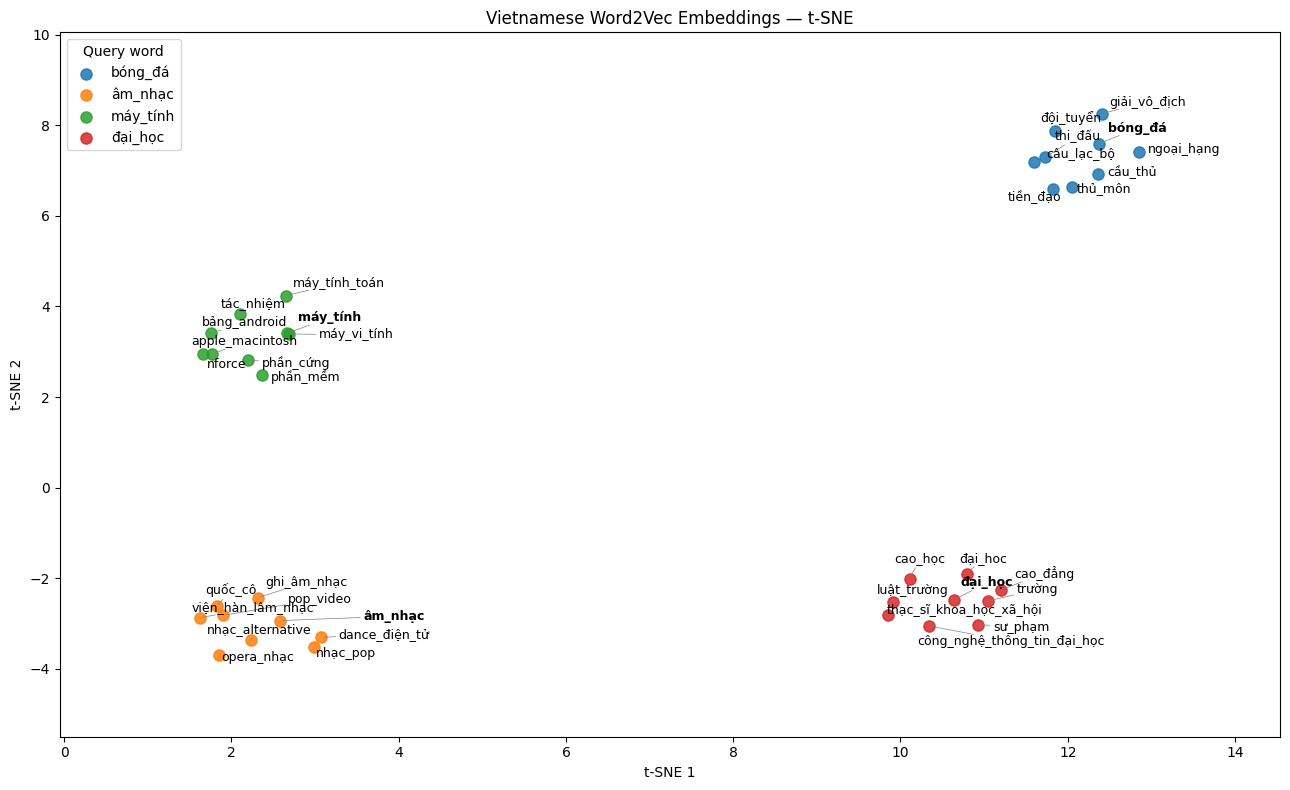

In [8]:
word_groups = {}
for query in available_queries:
    for word in [query] + [w for w, _ in similar[query]]:
        word_groups.setdefault(word, query)

words = list(word_groups)
vectors = np.array([model.wv.get_vector(word, norm=True) for word in words])
coordinates = TSNE(
    n_components=2, perplexity=min(10, len(words) - 1),
    init="pca", learning_rate="auto", random_state=SEED,
).fit_transform(vectors)

fig, ax = plt.subplots(figsize=(13, 8))
for query in available_queries:
    indices = [i for i, word in enumerate(words) if word_groups[word] == query]
    ax.scatter(coordinates[indices, 0], coordinates[indices, 1], label=query, s=65, alpha=0.85)
labels = [ax.text(*coordinates[i], word, fontsize=9,
                  fontweight="bold" if word in available_queries else "normal")
          for i, word in enumerate(words)]
ax.set(title="Vietnamese Word2Vec Embeddings — t-SNE", xlabel="t-SNE 1", ylabel="t-SNE 2")
ax.legend(title="Query word")
ax.margins(0.15)
fig.tight_layout()
np.random.seed(SEED)
adjust_text(labels, ax=ax, iter_lim=300,
            arrowprops={"arrowstyle": "-", "color": "gray", "lw": 0.5})
fig.savefig(OUTPUT_DIR / "word2vec_tsne.png", dpi=180, bbox_inches="tight")
plt.show()


## 5. Visualization Report

Biểu đồ thể hiện **36 từ** thuộc bốn nhóm truy vấn, từ mô hình **418,412 từ × 100 chiều**.

- Nhóm **bóng đá** tập trung quanh `cầu_thủ`, `thi_đấu`, `đội_tuyển`; cặp `bóng_đá`–`cầu_thủ` có cosine **0.8667**, phù hợp ngữ cảnh thể thao.
- Nhóm **máy tính** gồm `máy_vi_tính`, `phần_cứng`, `phần_mềm`; `máy_tính`–`máy_vi_tính` đạt **0.8829**. Nhóm **giáo dục** có `đại_học`, `trường`, `cao_đẳng`; `đại_học`–`trường` đạt **0.8908**.
- Nhóm **âm nhạc** có các từ liên quan như `nhạc_pop`, `nhạc_alternative`, nhưng cũng có token khó diễn giải như `quốc_cô`. Các dạng `đại_hoc`, `công_nghệ_thông_tin_đại_học` cho thấy dữ liệu và tách từ vẫn còn nhiễu.

Bốn nhóm khá tách biệt trên hình, nhưng các từ đã được chọn theo cosine nên không đại diện toàn vocabulary. Màu chỉ nhóm truy vấn; khoảng cách giữa nhóm trên t-SNE không phải thước đo ngữ nghĩa chính xác. Kết quả cho thấy mô hình học được một số quan hệ ngữ cảnh, chưa đủ để kết luận độ chính xác trên tác vụ khác.